# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for i, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[i] = (np.mean(scores), np.std(scores))
    


# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001], 
    'svm__kernel': ['rbf', 'linear'],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
df = pd.DataFrame(svm_grid_search.cv_results_)
df = df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
df.sort_values(by='rank_test_score')
df.head(10)

#results = pd.DataFrame([
 #   get_metrics(y_test, svm_no_scale),   # no_scale
  #  get_metrics(y_test, y_pred),   # with_scale
   # get_metrics(y_test, y_pred_best),   # best_grid
#], index=['no_scale', 'with_scale', 'best_grid'])

,params,mean_test_score,std_test_score,rank_test_score
0,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.940340,0.020136,22
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
2,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.937500,0.014005,23
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
4,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.638684,0.043638,24
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
7,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.964626,0.014950,11
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10
9,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.964626,0.014950,11


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20), 
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5] 
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rand_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
rand_search.fit(X_train, y_train)


print(f"Лучшие параметры RF: {rand_search.best_params_}")
print(f"Лучший CV F1: {rand_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 9, 'max_features': 0.5, 'min_samples_split': 4, 'n_estimators': 338}
Лучший CV F1: 0.9601


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [ ]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_baseline = Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))])
rf_baseline = RandomForestClassifier(random_state=42)

svm_baseline.fit(X_train, y_train)
rf_baseline.fit(X_train, y_train)

# Получаем лучшие модели из поиска
svm_best = svm_grid_search.best_estimator_
rf_best = rand_search.best_estimator_

# Получаем предсказания для всех моделей
svm_baseline_pred = svm_baseline.predict(X_test)
svm_best_pred = svm_best.predict(X_test)
rf_baseline_pred = rf_baseline.predict(X_test)
rf_best_pred = rf_best.predict(X_test)

results = []
mean_svm, std_svm = baseline_results['SVM']
results.append({
    "Модель": "SVM baseline",
    "CV F1": f"{mean_svm:.4f} ± {std_svm:.4f}",
    "Test F1": f1_score(y_test, svm_baseline_pred, average='macro')
})

results.append({
    "Модель": "SVM Grid Search",
    "CV F1": f"{svm_grid_search.best_score_:.4f}",
    "Test F1": f1_score(y_test, svm_best_pred, average='macro')
})

mean_rf, std_rf = baseline_results['RandomForest']
results.append({
    "Модель": "RF baseline",
    "CV F1": f"{mean_rf:.4f} ± {std_rf:.4f}",
    "Test F1": f1_score(y_test, rf_baseline_pred, average='macro')
})

results.append({
    "Модель": "RF Random Search",
    "CV F1": f"{rand_search.best_score_:.4f}",
    "Test F1": f1_score(y_test, rf_best_pred, average='macro')
})

# DataFrame
df_results = pd.DataFrame(results)
display(df_results)

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

,Модель,CV F1,Test F1
0,SVM baseline,0.9694 ± 0.0193,0.981151
1,SVM Grid Search,0.9786,0.981151
2,RF baseline,0.9504 ± 0.0255,0.952638
3,RF Random Search,0.9601,0.952638


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

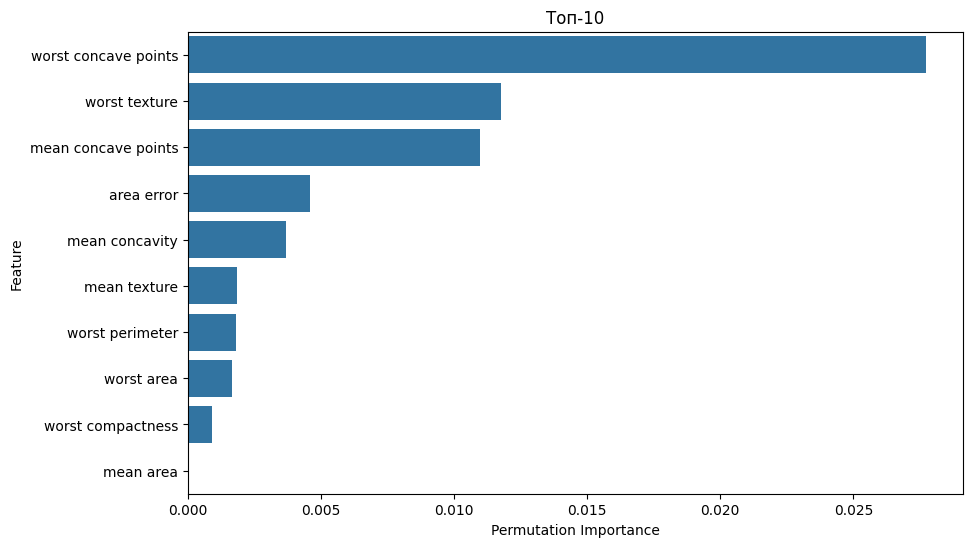

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rand_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

names = X_test.columns
mean = pi_result.importances_mean
std = pi_result.importances_std
data = pd.DataFrame({
    'feature': names,
    'importance'  :mean, 
    'std' : std
})
import seaborn as sns
data = data.sort_values(by='importance', ascending=False)
df1 = data.head(10)


plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=df1) 
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Топ-10')
#plt.tight_layout()
plt.show()

# Построим bar plot топ-10 признаков
# YOUR CODE HERE


In [ ]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков? Ответ: нет            ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝


# YOUR CODE HERE

pi_result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

pi_df = pd.DataFrame({
    'feature': X.columns,
    'pi_mean': pi_result.importances_mean,
    'pi_std': pi_result.importances_std
}).sort_values(by='pi_mean', ascending=False)

rf_df = pd.DataFrame({
    'feature': X.columns,
    'rf_importance': best_rf.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

top5_pi = pi_df.head(5)
top5_rf = rf_df.head(5)

print("Top-5 Permutation Importance:")
display(top5_pi)

print("Top-5 RF feature_importances_:")
display(top5_rf)


print(set(top5_pi['feature']) == set(top5_rf['feature']))
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

Top-5 Permutation Importance:


,feature,pi_mean,pi_std
27,worst concave points,0.027727,0.010319
21,worst texture,0.011754,0.007316
7,mean concave points,0.010983,0.007944
13,area error,0.004593,0.004593
6,mean concavity,0.003674,0.004500


Top-5 RF feature_importances_:


,feature,rf_importance
22,worst perimeter,0.247831
27,worst concave points,0.168665
23,worst area,0.142686
20,worst radius,0.137670
7,mean concave points,0.119219


Совпадают ли топ-5 признаки?
False


# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?
Ответ: Если высокий PI, но низкая важность - значит что важен для предсказаний, но в редко используется в разбияниях деревьев
наоборот - часто в деревьях , но не особо важен в предсказаниях

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

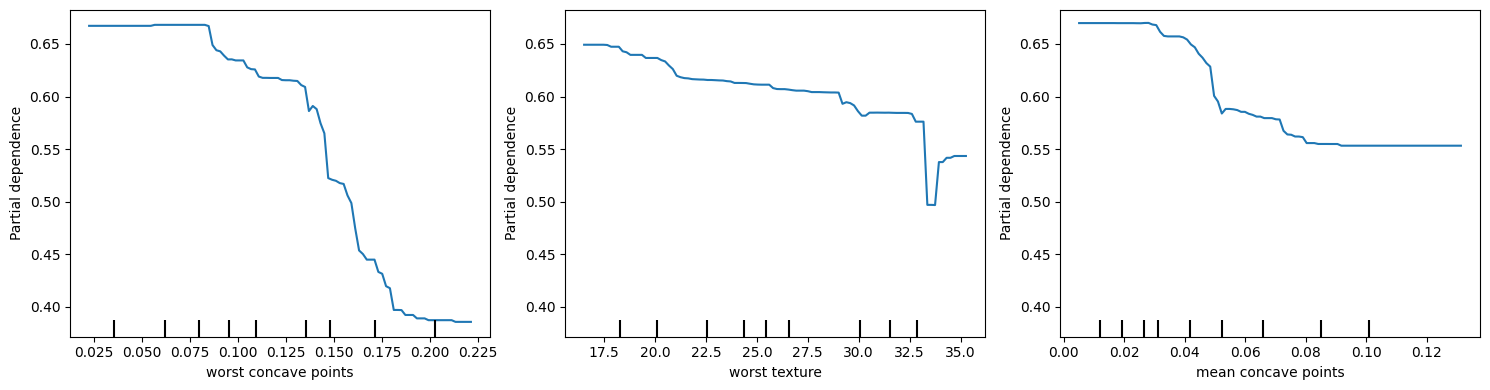

In [14]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top_3_pi = pi_df.head(3)
top3_idx = top_3_pi['feature'].tolist()# YOUR CODE HERE

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(estimator=best_rf, X=X_test, features=top3_idx, kind='average', ax=ax)
plt.tight_layout()
plt.show()

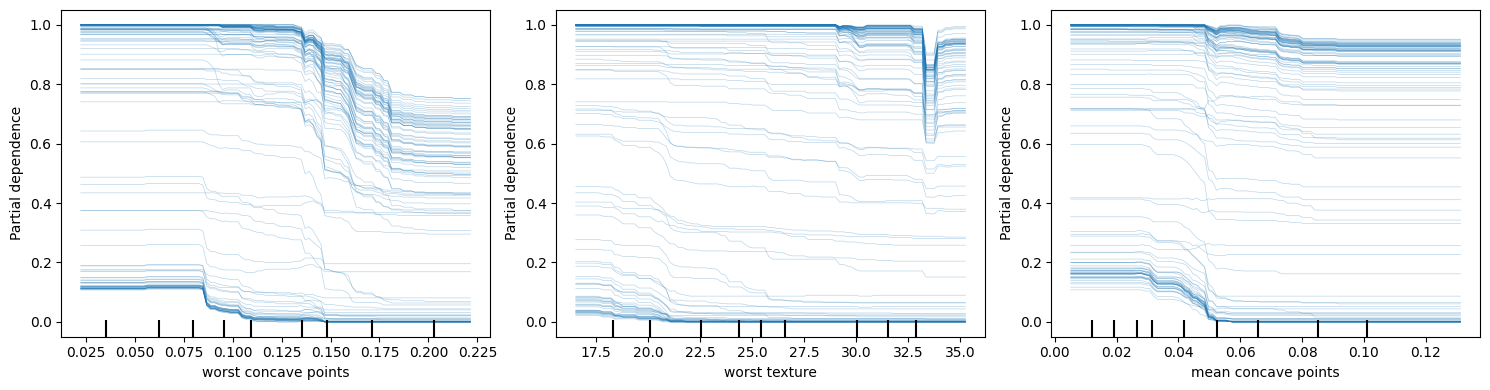

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
top_1_pi = pi_df.head(1)
top_idx = top_1_pi['feature'].tolist()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(estimator=best_rf, X=X_test, features=top3_idx, kind='individual', ax=ax)
plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [19]:
# Установка SHAP (если не установлен)
#%pip install shap

import shap as sh

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = sh.TreeExplainer(model=best_rf)
shap_values = explainer.shap_values(X=X_test)
#print(shap_values)
print(shap_values.shape)

(114, 30, 2)


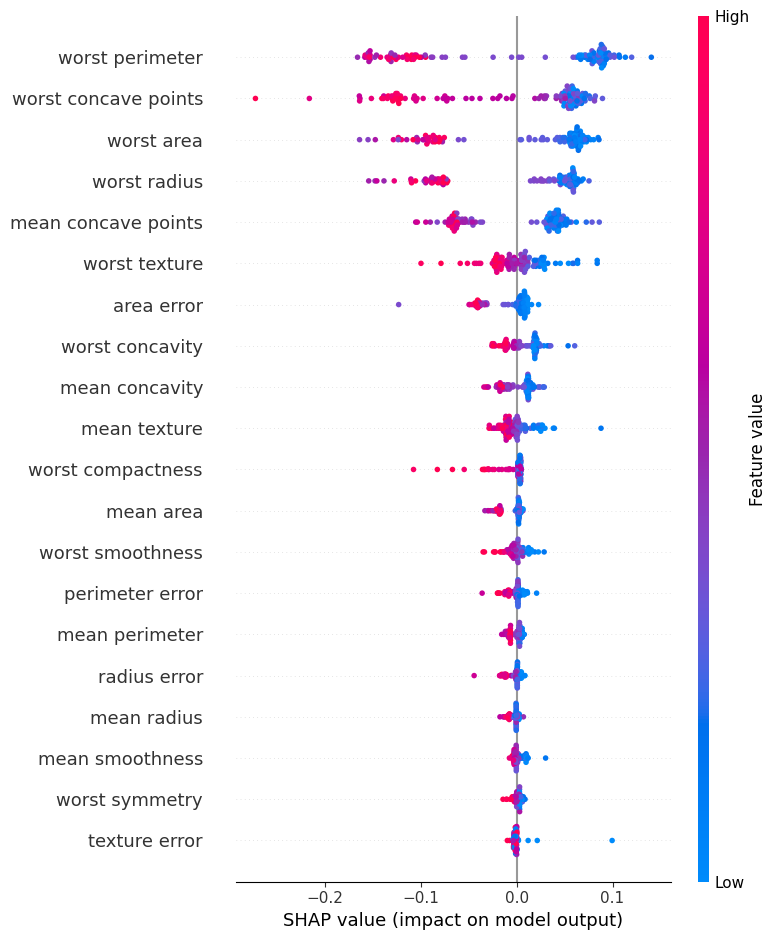

In [25]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap_values_class1 = shap_values[:, :, 1]

#fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
sh.summary_plot(shap_values_class1, X_test)



In [31]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
i = errors[0]
x = X_test.iloc[i]
sh.force_plot(
    explainer.expected_value[1],
    shap_values_class1[i],
    x
)


Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [32]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

,feature,importance
30,leaky_feature,0.263342
7,mean concave points,0.004689
27,worst concave points,0.003752
0,mean radius,0.000000
3,mean area,0.000000
4,mean smoothness,0.000000
2,mean perimeter,0.000000
1,mean texture,0.000000
8,mean symmetry,0.000000
9,mean fractal dimension,0.000000


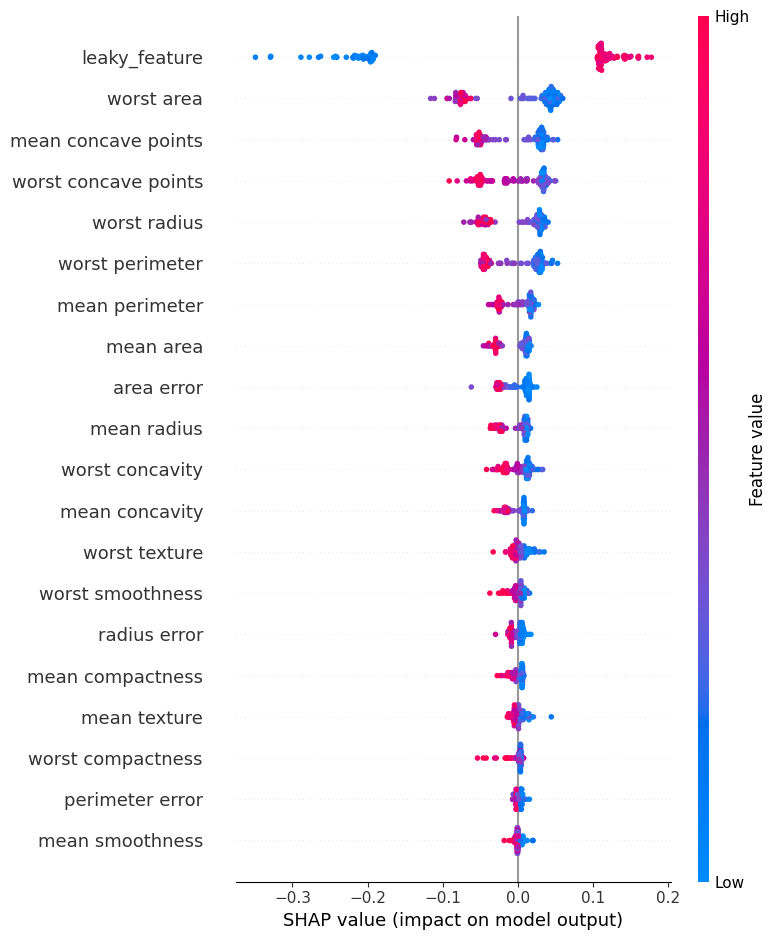

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)

pi_ext = permutation_importance(
    rf_ext,
    X_test_ext,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

pi_df_ext = pd.DataFrame({
    'feature': X_test_ext.columns,
    'importance': pi_ext.importances_mean
}).sort_values(by='importance', ascending=False)

display(pi_df_ext.head(10))

explainer_ext = sh.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
shap_values_class1_ext = shap_values_ext[:, :, 1]

sh.summary_plot(shap_values_class1_ext, X_test_ext)

Ответы на вопросы:
a) leaky_feature определяется как самый важный признак, так как он почти полностью совпадает с целевой переменной. Метрика на тесте выросла, потому что модель по сути получает информацию о правильном ответе, что есть data leakage.
б) SHAP выделяет leaky_feature как наиболее важный признак. Значения SHAP для этого признака имеют большой разброс, что означает сильное влияние на предсказания модели. Это связано с тем, что признак практически напрямую кодирует целевую переменную.
в) random_feature определяется как шумовой признак, так как его Permutation Importance близка к нулю. В SHAP summary plot его значения сосредоточены около нуля, что означает отсутствие значимого влияния на предсказания.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
results = []

results.append({
    "Метод": "SVM baseline",
    "CV F1": f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
    "Test F1": f"{f1_score(y_test, svm_baseline_pred, average='macro'):.4f}",
    "Выводы": "Базовая модель"
})

results.append({
    "Метод": "SVM Grid Search",
    "CV F1": f"{svm_grid_search.best_score_:.4f}",
    "Test F1": f"{f1_score(y_test, svm_best_pred, average='macro'):.4f}",
    "Выводы": "Тюнинг улучшил качество за счет подбора параметров"
})

results.append({
    "Метод": "RF baseline",
    "CV F1": f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
    "Test F1": f"{f1_score(y_test, rf_baseline_pred, average='macro'):.4f}",
    "Выводы": "Стабильная модель, но без оптимизации"
})

results.append({
    "Метод": "RF Random Search",
    "CV F1": f"{rand_search.best_score_:.4f}",
    "Test F1": f"{f1_score(y_test, rf_best_pred, average='macro'):.4f}",
    "Выводы": "Хорошее качество после подбора гиперпараметров"
})

df_final = pd.DataFrame(results)
display(df_final)

,Метод,CV F1,Test F1,Выводы
0,SVM baseline,0.9694 ± 0.0193,0.9812,"Базовая модель, без настройки гиперпараметров"
1,SVM Grid Search,0.9786,0.9812,Тюнинг улучшил качество за счет подбора параме...
2,RF baseline,0.9504 ± 0.0255,0.9526,"Стабильная модель, но без оптимизации"
3,RF Random Search,0.9601,0.9526,Лучшее качество благодаря подбору параметров


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
%pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")